**Author**: Felipe Matheus <br>
**Start Date**: 06/05/2026 <br>
**End Date**: --/0/2026 <br>
**Related Links**:

- Results so far: https://docs.google.com/spreadsheets/d/1OnIWY_bKxgdGU3trECDTL971WfXFPWgbW-dQzgP6KhI/edit?gid=0#gid=0

- Dataset used: https://drive.google.com/drive/u/0/folders/1VsU-taxtwfmDLUu5Z4JmdgXSoxUoB8FI


**Objective** 

The objective of this notebook is to develop a probabilistic **prediction** model for **conductivity** after the **Annealing** process of given alloys. Using AutoGluon.

# Setup

In [2]:
import os
import sys
import h2o
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from h2o.automl import H2OAutoML

module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.processing.Processing import Processing
from src.feature_engineering.FeatureEngineering import FeatureEngineering
# from src.visualization.Plots import Plots
# from src.visualization.Visualization import Visualization
# from src.metrics.Evaluations import Evaluations
# from src.feature_engineering.Scaler import ScalerHelpers

from config.Variables import Variables

# from src.utils import pick_best_non_ensemble, get_good_key

%load_ext autoreload
%autoreload 2

In [3]:
varv = Variables()

In [4]:
proc = Processing()
# plot = Plots()
feng = FeatureEngineering()
# visu = Visualization()
# evla = Evaluations()
# scla = ScalerHelpers()

In [5]:
PATH_DATA_RAW = "../../data/raw" 
FILE_NAME_IACS = "dataset_annealing_iacs.csv"

TARGET_VARIABLE = "iacs_final"

PATH_MODELS = "../../models"
PROCESS = "annealing_iacs"


In [6]:
# dfs_to_train = {}
scalers = {}
dfs_norm = {}
hfs = {}
amls = {}
results = {}

In [7]:
varv

{'FEATURES_RANGE_AN': None, 'FEATURES_RANGE_CD': None, 'PATHS': {'data_raw': '../../data/raw/', 'data_processed': '../../data/processed/', 'data_enriched': '../../data/enriched/', 'models': '../../models/'}}

In [8]:
df_iacs = pd.read_csv(os.path.join(PATH_DATA_RAW, FILE_NAME_IACS))
df_iacs

,material,purity,grain_size,iacs,temperature,time,grain_size_final,iacs_final
0,Cu,99.98,320,97,473,30,~500,100
1,Cu,99.98,320,97,523,600,~800,100
2,Cu,99.98,320,97,573,120,~900,103
3,Cu,99.98,320,96,473,30,~500,99
4,Cu,99.98,320,95,523,600,~800,98
...,...,...,...,...,...,...,...,...
126,Al–0.5Mg–0.5Si (wt%),~99.7,250,58,623,60,~2000,~67.4
127,Al–0.5Mg–0.5Si (wt%),~99.7,250,58,623,120,~2500,~68.2
128,Al–Mn–Mg alloy,~99.5,250,~35,423,60,~400,~38
129,Al–Mn–Mg alloy,~99.5,250,~35,523,60,~800,~43


In [9]:
df_float = proc.df_to_float(
    df_iacs,
    drop_cols=["DOI"], ignore_columns=["material"],
)

df_labeled_unique = feng.label_element(df_float).drop_duplicates()
df_to_mask = \
    feng.add_ratio_mask_column(
        feng.add_ratio_mask_column(df_labeled_unique, "grain_size"),
        "iacs",
    )
df_to_mask

c:\Users\fmfoa\Projects\uncertainty-aware-predictors\src\processing\Processing.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_float = df_float.applymap(
c:\Users\fmfoa\Projects\uncertainty-aware-predictors\src\processing\Processing.py:37: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_float = df_float.applymap(


,material,purity,grain_size,iacs,temperature,time,grain_size_final,iacs_final,has_Cu,grain_size_ratio,iacs_ratio
0,Cu,99.98,320.0,97.0,473.0,30.0,500.0,100.0,True,1.5625,1.030928
1,Cu,99.98,320.0,97.0,523.0,600.0,800.0,100.0,True,2.5000,1.030928
2,Cu,99.98,320.0,97.0,573.0,120.0,900.0,103.0,True,2.8125,1.061856
3,Cu,99.98,320.0,96.0,473.0,30.0,500.0,99.0,True,1.5625,1.031250
4,Cu,99.98,320.0,95.0,523.0,600.0,800.0,98.0,True,2.5000,1.031579
...,...,...,...,...,...,...,...,...,...,...,...
126,Al–0.5Mg–0.5Si (wt%),99.70,250.0,58.0,623.0,60.0,2000.0,67.4,False,8.0000,1.162069
127,Al–0.5Mg–0.5Si (wt%),99.70,250.0,58.0,623.0,120.0,2500.0,68.2,False,10.0000,1.175862
128,Al–Mn–Mg alloy,99.50,250.0,35.0,423.0,60.0,400.0,38.0,False,1.6000,1.085714
129,Al–Mn–Mg alloy,99.50,250.0,35.0,523.0,60.0,800.0,43.0,False,3.2000,1.228571


In [10]:
columns_to_drop = [
    "material",
    "has_Cu",
    "grain_size_ratio",
    "iacs_ratio",
]
mask_cu = df_to_mask.has_Cu == True

df = df_to_mask[mask_cu].drop(columns=columns_to_drop)
df

,purity,grain_size,iacs,temperature,time,grain_size_final,iacs_final
0,99.98,320.0,97.0,473.0,30.0,500.0,100.0
1,99.98,320.0,97.0,523.0,600.0,800.0,100.0
2,99.98,320.0,97.0,573.0,120.0,900.0,103.0
3,99.98,320.0,96.0,473.0,30.0,500.0,99.0
4,99.98,320.0,95.0,523.0,600.0,800.0,98.0
...,...,...,...,...,...,...,...
99,99.00,180.0,88.0,673.0,30.0,450.0,97.0
100,99.00,190.0,87.0,473.0,30.0,270.0,89.0
101,99.00,190.0,87.0,573.0,30.0,350.0,92.0
102,99.00,190.0,87.0,673.0,30.0,480.0,95.0


# Modeling

In [11]:
TARGET = "iacs_final"
FEATURES = ["purity", "iacs", "temperature", "time"]

In [12]:
df = df[FEATURES + [TARGET]]

## Training

In [13]:
from autogluon.tabular import TabularPredictor

predictor_t = TabularPredictor(
    label=TARGET,
    eval_metric="root_mean_squared_error",
    path="./model_a",
).fit(
    df,
    num_bag_folds=5,                # ← faz o CV internamente
    num_bag_sets=1,
    num_stack_levels=5,             # sem stacking; mantém simples
    time_limit=30,
)

c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       14.16 GB / 31.57 GB (44.8%)
Disk Space Avail:   756.92 GB / 932.08 GB (81.2%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : New in v1.5: 

RuntimeError: No models were trained successfully during fit(). Inspect the log output or increase verbosity to determine why no models were fit. Alternatively, set `raise_on_no_models_fitted` to False during the fit call.

In [ ]:
predictor_t.leaderboard()

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L6,-6.795045,root_mean_squared_error,0.043802,6.637133,0.000000,0.002672,6,True,11
1,LightGBMXT_BAG_L5,-6.795045,root_mean_squared_error,0.043802,6.634460,0.007447,1.727102,5,True,10
2,WeightedEnsemble_L7,-6.795045,root_mean_squared_error,0.044806,6.637986,0.001004,0.003526,7,True,12
3,WeightedEnsemble_L2,-6.814033,root_mean_squared_error,0.007708,0.784675,0.000000,0.007915,2,True,2
4,LightGBMXT_BAG_L1,-6.814033,root_mean_squared_error,0.007708,0.776760,0.007708,0.776760,1,True,1
5,WeightedEnsemble_L5,-6.920484,root_mean_squared_error,0.036356,4.907358,0.000000,0.000000,5,True,9
6,LightGBMXT_BAG_L4,-6.920484,root_mean_squared_error,0.036356,4.907358,0.010221,1.312306,4,True,8
7,WeightedEnsemble_L3,-6.969854,root_mean_squared_error,0.017587,2.387407,0.000000,0.003230,3,True,5
8,LightGBM_BAG_L2,-6.969854,root_mean_squared_error,0.017587,2.384177,0.009879,1.607418,2,True,4
9,LightGBMXT_BAG_L2,-6.974515,root_mean_squared_error,0.011784,2.428135,0.004076,1.651376,2,True,3


In [ ]:
from autogluon.tabular import TabularPredictor

predictor_a = TabularPredictor(
    label=TARGET,
    eval_metric="root_mean_squared_error",
    path="./model_a",
).fit(
    df,
    presets="best_quality",      # rápido para iteração
    num_bag_folds=5,                # ← faz o CV internamente
    num_bag_sets=1,
    num_stack_levels=0,             # sem stacking; mantém simples
    time_limit=120,
)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       7.89 GB / 31.57 GB (25.0%)
Disk Space Avail:   756.61 GB / 932.08 GB (81.2%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Stack configuration (auto_stack=True): num_stack_levels=0, num_bag_folds=5, num_bag_sets=1
Beginning AutoGluon training ... Time limit = 120s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\notebooks\modeling\model_a"
Train Data Rows:    87
Train Data Columns: 4
Label Column:       iacs_final
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label info (max, min, mea

KeyboardInterrupt: 

In [ ]:
predictor_a.leaderboard()

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-4.196348,root_mean_squared_error,0.094246,48.130619,0.000000,0.007463,2,True,11
1,CatBoost_r177_BAG_L1,-4.519977,root_mean_squared_error,0.006527,30.006618,0.006527,30.006618,1,True,10
2,ExtraTreesMSE_BAG_L1,-4.536094,root_mean_squared_error,0.025738,0.355187,0.025738,0.355187,1,True,5
3,CatBoost_BAG_L1,-4.861159,root_mean_squared_error,0.009119,33.493303,0.009119,33.493303,1,True,4
4,NeuralNetTorch_BAG_L1,-4.921912,root_mean_squared_error,0.030294,10.831105,0.030294,10.831105,1,True,8
5,RandomForestMSE_BAG_L1,-5.072580,root_mean_squared_error,0.027606,0.672020,0.027606,0.672020,1,True,3
6,NeuralNetFastAI_BAG_L1,-5.622132,root_mean_squared_error,0.031687,6.930246,0.031687,6.930246,1,True,6
7,LightGBMLarge_BAG_L1,-5.768619,root_mean_squared_error,0.011771,1.752143,0.011771,1.752143,1,True,9
8,XGBoost_BAG_L1,-6.038894,root_mean_squared_error,0.018186,0.833689,0.018186,0.833689,1,True,7
9,LightGBM_BAG_L1,-6.653741,root_mean_squared_error,0.004950,0.833549,0.004950,0.833549,1,True,2


In [ ]:
predictor_a.fit_summary()

*** Summary of fit() ***
Estimated performance of each model:
                     model  score_val              eval_metric  pred_time_val   fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0      WeightedEnsemble_L2  -4.196348  root_mean_squared_error       0.094246  48.130619                0.000000           0.007463            2       True         11
1     CatBoost_r177_BAG_L1  -4.519977  root_mean_squared_error       0.006527  30.006618                0.006527          30.006618            1       True         10
2     ExtraTreesMSE_BAG_L1  -4.536094  root_mean_squared_error       0.025738   0.355187                0.025738           0.355187            1       True          5
3          CatBoost_BAG_L1  -4.861159  root_mean_squared_error       0.009119  33.493303                0.009119          33.493303            1       True          4
4    NeuralNetTorch_BAG_L1  -4.921912  root_mean_squared_error       0.030294  10.831105               

c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\autogluon\core\utils\plots.py:169: UserWarning: AutoGluon summary plots cannot be created because bokeh is not installed. To see plots, please do: "pip install bokeh==2.0.1"
  warnings.warn('AutoGluon summary plots cannot be created because bokeh is not installed. To see plots, please do: "pip install bokeh==2.0.1"')


{'model_types': {'LightGBMXT_BAG_L1': 'StackerEnsembleModel_LGB',
  'LightGBM_BAG_L1': 'StackerEnsembleModel_LGB',
  'RandomForestMSE_BAG_L1': 'StackerEnsembleModel_RF',
  'CatBoost_BAG_L1': 'StackerEnsembleModel_CatBoost',
  'ExtraTreesMSE_BAG_L1': 'StackerEnsembleModel_XT',
  'NeuralNetFastAI_BAG_L1': 'StackerEnsembleModel_NNFastAiTabular',
  'XGBoost_BAG_L1': 'StackerEnsembleModel_XGBoost',
  'NeuralNetTorch_BAG_L1': 'StackerEnsembleModel_TabularNeuralNetTorch',
  'LightGBMLarge_BAG_L1': 'StackerEnsembleModel_LGB',
  'CatBoost_r177_BAG_L1': 'StackerEnsembleModel_CatBoost',
  'WeightedEnsemble_L2': 'WeightedEnsembleModel'},
 'model_performance': {'LightGBMXT_BAG_L1': np.float64(-6.814033349688588),
  'LightGBM_BAG_L1': np.float64(-6.653740518598885),
  'RandomForestMSE_BAG_L1': np.float64(-5.072580317354586),
  'CatBoost_BAG_L1': np.float64(-4.8611591162825905),
  'ExtraTreesMSE_BAG_L1': np.float64(-4.536093862793251),
  'NeuralNetFastAI_BAG_L1': np.float64(-5.622132152048469),
  'XG

In [ ]:
predictor_b = TabularPredictor(label=TARGET).fit(df)

No path specified. Models will be saved in: "AutogluonModels\ag-20260506_101035"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       10.51 GB / 31.57 GB (33.3%)
Disk Space Avail:   766.29 GB / 932.08 GB (82.2%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : New in v1.5: The state-of-the-art for tabular data. Massively better than 'best' on datasets <100000 samples by using new Tabular Foundation Models (TFMs) meta-learned on https://tabarena.ai: TabPFNv2, TabICL, Mitr

In [ ]:
predictor_b.leaderboard()

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-7.542050,root_mean_squared_error,0.006143,1.553674,0.000000,0.006150,2,True,10
1,LightGBMLarge,-7.641833,root_mean_squared_error,0.000000,0.270148,0.000000,0.270148,1,True,9
2,CatBoost,-7.682361,root_mean_squared_error,0.000000,0.348642,0.000000,0.348642,1,True,4
3,NeuralNetFastAI,-8.142042,root_mean_squared_error,0.006143,0.928734,0.006143,0.928734,1,True,6
4,ExtraTreesMSE,-8.469050,root_mean_squared_error,0.035293,0.330932,0.035293,0.330932,1,True,5
5,RandomForestMSE,-8.563541,root_mean_squared_error,0.023708,0.319765,0.023708,0.319765,1,True,3
6,XGBoost,-8.798284,root_mean_squared_error,0.002756,0.234353,0.002756,0.234353,1,True,7
7,NeuralNetTorch,-8.855530,root_mean_squared_error,0.007674,1.669479,0.007674,1.669479,1,True,8
8,LightGBMXT,-9.160168,root_mean_squared_error,0.000000,0.219026,0.000000,0.219026,1,True,1
9,LightGBM,-9.179516,root_mean_squared_error,0.000000,0.158782,0.000000,0.158782,1,True,2


In [ ]:
predictor_c = TabularPredictor(label=TARGET).fit(df, presets="best_quality",)

No path specified. Models will be saved in: "AutogluonModels\ag-20260506_101340"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       10.95 GB / 31.57 GB (34.7%)
Disk Space Avail:   766.27 GB / 932.08 GB (82.2%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	T

In [ ]:
predictor_c.predict_oof()

0      99.511345
1      98.490883
2      97.346123
3      98.805214
4      97.819366
         ...    
99     95.289230
100    92.028435
101    92.219696
102    95.531036
112    91.102783
Name: iacs_final, Length: 87, dtype: float32

In [ ]:
predictor_c.predict_proba_oof()

0      99.511345
1      98.490883
2      97.346123
3      98.805214
4      97.819366
         ...    
99     95.289230
100    92.028435
101    92.219696
102    95.531036
112    91.102783
Name: iacs_final, Length: 87, dtype: float32

## Assesment

In [ ]:
summary = predictor_c.fit_summary(verbosity=0)

print(summary["model_performance"])   # {model_name: val_score}
print(summary["model_fit_times"])     # {model_name: seconds}
print(summary["model_pred_times"])

{'LightGBMXT_BAG_L1': np.float64(-5.749728112596087), 'LightGBM_BAG_L1': np.float64(-5.726765371035901), 'RandomForestMSE_BAG_L1': np.float64(-5.072580317354586), 'CatBoost_BAG_L1': np.float64(-3.913855106226763), 'ExtraTreesMSE_BAG_L1': np.float64(-4.536093862793251), 'NeuralNetFastAI_BAG_L1': np.float64(-5.366271406578243), 'XGBoost_BAG_L1': np.float64(-4.933139220863701), 'NeuralNetTorch_BAG_L1': np.float64(-3.7573315693764155), 'LightGBMLarge_BAG_L1': np.float64(-4.7461349130590165), 'CatBoost_r177_BAG_L1': np.float64(-3.9243384454112404), 'NeuralNetTorch_r79_BAG_L1': np.float64(-4.1348804196782405), 'LightGBM_r131_BAG_L1': np.float64(-5.44562554942961), 'NeuralNetFastAI_r191_BAG_L1': np.float64(-4.652486200597091), 'CatBoost_r9_BAG_L1': np.float64(-4.04037471587866), 'LightGBM_r96_BAG_L1': np.float64(-11.991372918566597), 'NeuralNetTorch_r22_BAG_L1': np.float64(-3.760096913585867), 'XGBoost_r33_BAG_L1': np.float64(-4.54959128100521), 'ExtraTrees_r42_BAG_L1': np.float64(-4.73748961

In [ ]:
predictor_c.ge

In [ ]:
print("A best model:", predictor_a.model_best)
print("B best model:", predictor_b.model_best)

A best model: WeightedEnsemble_L2
B best model: WeightedEnsemble_L2


## Step by step 

In [ ]:
predictor = TabularPredictor(
    label=TARGET,
    eval_metric="root_mean_squared_error",
    path="./model_test",
).fit(
    df,
    presets="medium_quality",      # rápido para iteração
    num_bag_folds=5,                # ← faz o CV internamente
    num_bag_sets=1,
    num_stack_levels=0,             # sem stacking; mantém simples
    time_limit=120,
)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       6.78 GB / 31.57 GB (21.5%)
Disk Space Avail:   756.60 GB / 932.08 GB (81.2%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 120s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\notebooks\modeling\model_test"
Train Data Rows:    87
Train Data Columns: 4
Label Column:       iacs_final
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label info (max, min, mean, stddev): (105.0, 48.0, 88.01839, 11.9712)
	If 'regression' is not the correct proble

In [ ]:
import numpy as np

# OOF mean prediction (one per training row)
mu_oof = predictor.predict_oof()  # Series, mesma indexação de df

# OOF residuals
residuals_oof = df[TARGET] - mu_oof

# Epistemic variance: dispersão entre base learners.
# Para extrair predições por modelo, precisamos rodar predict_multi
# em cada linha. Mas predict_multi não é OOF nativo, então tem um truque:
# usamos as predições OOF de cada modelo individual e calculamos var.

# AutoGluon expõe via:
oof_per_model = {}
for model_name in predictor.model_names():
    # try:
    oof_per_model[model_name] = predictor.predict_oof(model=model_name)
    # except Exception:
    #     pass  # nem todo modelo tem OOF (ex.: weighted ensemble)

# Empilha em matriz (M, N)
oof_matrix = np.stack([s.values for s in oof_per_model.values()])
sigma2_epist_oof = oof_matrix.var(axis=0, ddof=0)  # uma variância por linha

In [ ]:
mu_epist_oof = oof_matrix.mean(axis=0)
mu_epist_oof

array([ 97.659744, 100.3409  ,  98.82682 ,  97.885414,  98.18144 ,
        98.63292 ,  95.855675,  73.13337 ,  79.1382  ,  75.21775 ,
        71.139244,  75.40357 ,  82.99025 ,  85.594734,  87.59533 ,
        74.390785,  74.35538 ,  78.205444,  82.118324,  83.28247 ,
        84.983604,  84.74146 ,  87.60555 ,  81.86397 ,  85.6807  ,
        86.6896  ,  72.99815 ,  77.21832 ,  80.2627  ,  66.64757 ,
        57.265617,  60.202057,  63.31787 ,  99.009155,  99.8616  ,
        98.72084 ,  99.5947  , 100.33586 , 100.659706, 102.27911 ,
       101.59748 , 100.01942 , 103.17476 ,  95.369965,  96.73757 ,
        98.725945,  94.521286,  96.9922  ,  97.956345,  92.96297 ,
        95.393105,  97.635544,  90.10301 ,  92.75156 ,  95.10227 ,
        88.325165,  90.89021 ,  91.75837 ,  88.707794,  92.40961 ,
        94.363144,  80.19978 ,  81.73253 ,  84.52847 ,  78.96481 ,
        80.332825,  83.164246,  83.5629  ,  84.9749  ,  85.72958 ,
        87.82689 ,  91.061455,  92.8477  ,  92.62792 ,  76.788

In [ ]:
predictor.predict_oof()

0       98.680832
1      101.395653
2       98.298355
3       98.008163
4       98.272850
          ...    
99      95.328766
100     90.887489
101     92.828773
102     95.353951
112     87.485992
Name: iacs_final, Length: 87, dtype: float32

In [ ]:
predictor.predict_oof(model="XGBoost_BAG_L1")

0       95.674286
1      101.965431
2       99.305702
3       95.878220
4       96.999718
          ...    
99      94.625778
100     90.758026
101     91.613754
102     95.112144
112     93.948524
Name: iacs_final, Length: 87, dtype: float32

In [22]:
predictor.model_names()

['LightGBMXT_BAG_L1',
 'LightGBM_BAG_L1',
 'RandomForestMSE_BAG_L1',
 'CatBoost_BAG_L1',
 'ExtraTreesMSE_BAG_L1',
 'NeuralNetFastAI_BAG_L1',
 'XGBoost_BAG_L1',
 'NeuralNetTorch_BAG_L1',
 'LightGBMLarge_BAG_L1',
 'WeightedEnsemble_L2']

In [23]:
mu_oof

0       98.680832
1      101.395653
2       98.298355
3       98.008163
4       98.272850
          ...    
99      95.328766
100     90.887489
101     92.828773
102     95.353951
112     87.485992
Name: iacs_final, Length: 87, dtype: float32

In [24]:
sigma2_epist_oof

array([ 2.50388   ,  5.3467226 ,  4.9575334 ,  1.8783436 ,  0.47590894,
        5.4936666 ,  1.456461  ,  3.9073155 ,  7.706727  , 22.734324  ,
       15.952016  ,  2.9615817 ,  1.7238535 ,  6.4190545 ,  3.5238252 ,
       83.74355   , 15.021605  ,  9.206015  ,  7.279969  ,  2.4002814 ,
        0.761828  ,  1.2096847 ,  1.185199  ,  1.9325361 ,  9.61635   ,
       10.368009  , 23.298521  , 13.6886215 , 16.711817  , 45.714314  ,
       34.715084  , 31.331165  , 27.981165  ,  3.3133373 ,  3.7337792 ,
        5.5128    ,  4.470621  ,  3.261413  ,  4.3793106 ,  1.4436495 ,
        5.3080626 ,  8.254581  ,  1.9805737 ,  0.26767462,  0.9824427 ,
        2.408936  ,  2.7345166 ,  3.0905862 ,  1.1093938 ,  2.8089948 ,
        5.4041405 ,  2.5891287 ,  0.38837987,  1.1168249 ,  0.4434844 ,
        0.6215582 ,  1.4866196 ,  2.8765984 ,  1.4913318 ,  1.036048  ,
        1.0572952 ,  2.5502176 ,  2.2627864 ,  4.7125216 ,  3.055838  ,
        3.3477535 ,  4.622231  ,  1.8663727 ,  1.4189532 ,  1.50

(array([13., 16.,  9.,  9.,  5.,  5.,  5.,  1.,  3.,  1.,  2.,  1.,  1.,
         0.,  0.,  0.,  1.,  1.,  2.,  1.,  1.,  0.,  1.,  1.,  0.,  0.,
         1.,  1.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  1.,  0.,
         0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([ 0.26767462,  1.10243344,  1.9371922 ,  2.77195096,  3.60670972,
         4.44146824,  5.276227  ,  6.11098576,  6.94574451,  7.78050327,
         8.61526203,  9.45002079, 10.28477955, 11.11953831, 11.95429707,
        12.78905582, 13.62381458, 14.45857334, 15.2933321 , 16.12809181,
        16.96285057, 17.79760933, 18.63236809, 19.46712685, 20.3018856 ,
        21.13664436, 21.97140312, 22.80616188, 23.64092064, 24.475679

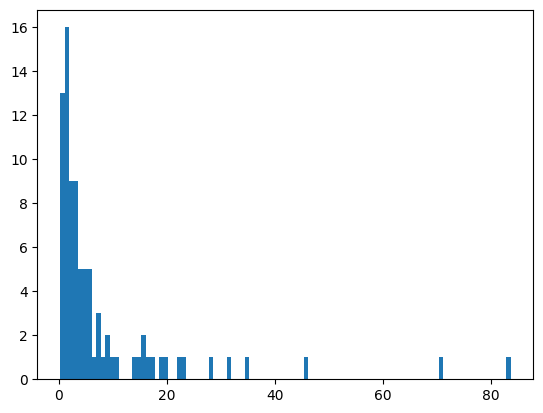

In [25]:
plt.hist(sigma2_epist_oof, bins=100)

In [27]:
predictor.model_names()

['LightGBMXT_BAG_L1',
 'LightGBM_BAG_L1',
 'RandomForestMSE_BAG_L1',
 'CatBoost_BAG_L1',
 'ExtraTreesMSE_BAG_L1',
 'NeuralNetFastAI_BAG_L1',
 'XGBoost_BAG_L1',
 'NeuralNetTorch_BAG_L1',
 'LightGBMLarge_BAG_L1',
 'WeightedEnsemble_L2']

In [28]:
predictor.predict_oof(model="XGBoost_BAG_L1")

0       95.674286
1      101.965431
2       99.305702
3       95.878220
4       96.999718
          ...    
99      94.625778
100     90.758026
101     91.613754
102     95.112144
112     93.948524
Name: iacs_final, Length: 87, dtype: float32

In [29]:
predictor.predict_oof(model="WeightedEnsemble_L2")

0       98.680832
1      101.395653
2       98.298355
3       98.008163
4       98.272850
          ...    
99      95.328766
100     90.887489
101     92.828773
102     95.353951
112     87.485992
Name: iacs_final, Length: 87, dtype: float32

In [30]:
mu_oof

0       98.680832
1      101.395653
2       98.298355
3       98.008163
4       98.272850
          ...    
99      95.328766
100     90.887489
101     92.828773
102     95.353951
112     87.485992
Name: iacs_final, Length: 87, dtype: float32

In [31]:
residuals_oof

0      1.319168
1     -1.395653
2      4.701645
3      0.991837
4     -0.272850
         ...   
99     1.671234
100   -1.887489
101   -0.828773
102   -0.353951
112   -7.485992
Name: iacs_final, Length: 87, dtype: float64

In [32]:
oof_matrix.shape

(10, 87)

In [33]:
oof_matrix

array([[ 96.81834 ,  96.631615,  98.37153 ,  97.14202 ,  98.83842 ,
         96.631615,  96.69142 ,  72.46216 ,  78.46979 ,  71.448074,
         75.27062 ,  74.91859 ,  82.497345,  82.65172 ,  85.8056  ,
         82.18677 ,  81.917725,  81.2146  ,  81.917725,  82.50275 ,
         86.17653 ,  84.980965,  86.90996 ,  82.50275 ,  81.2146  ,
         81.917725,  81.022835,  80.49024 ,  77.77233 ,  72.46216 ,
         69.67264 ,  70.110275,  72.36411 ,  96.11453 ,  96.11453 ,
         94.97682 ,  97.284424,  96.631615,  98.37153 , 100.54218 ,
         99.19742 , 102.1947  , 100.82607 ,  96.11453 ,  98.37153 ,
        101.00817 ,  97.14202 , 100.66521 , 100.31131 ,  96.11453 ,
        100.0848  , 100.82607 ,  89.228004,  93.35283 ,  96.6235  ,
         87.67289 ,  91.85581 ,  92.10162 ,  88.46111 ,  93.65565 ,
         94.119514,  81.23286 ,  82.50275 ,  83.403206,  81.93247 ,
         82.50275 ,  83.403206,  80.911575,  84.628746,  83.21918 ,
         85.88319 ,  88.947655,  88.932915,  91.

In [35]:
final_model_name = predictor.model_best
ens_model = predictor._trainer.load_model(final_model_name)

print("Tipo do ens_model:", type(ens_model).__name__)
print("\nAtributos relevantes:")
for attr in dir(ens_model):
    if 'weight' in attr.lower() or 'base_model' in attr.lower() or 'child' in attr.lower():
        print(f"  {attr}")

print("\nens_model.model é:", ens_model.model)

Tipo do ens_model: WeightedEnsembleModel

Atributos relevantes:
  _add_child_num_cpus
  _add_child_num_gpus
  _add_child_times_to_bag
  _add_parallel_child_times
  _base_model_performances_dict
  _base_model_types_inner_dict
  _child_num_cpus
  _child_num_gpus
  _child_oof
  _child_type
  _get_child_aux_val
  _get_child_info
  _get_child_model_names
  _get_dynamic_max_base_models_per_type
  _get_model_weights
  _get_tags_child
  _params_aux_child
  add_child
  base_model_names
  base_model_paths_dict
  base_model_types_dict
  base_models_dict
  can_estimate_memory_usage_static_child
  convert_to_refit_full_template_child
  convert_to_template_child
  estimate_memory_usage_child
  estimate_memory_usage_static_child
  fit_num_cpus_child
  fit_num_gpus_child
  get_hyperparameters_init_child
  load_base_model
  load_child
  n_children
  persist_child_models
  predict_children
  predict_proba_children
  save_child
  unpersist_child_models

ens_model.model é: None


In [36]:
import numpy as np
from scipy.optimize import nnls

# oof_matrix: (M, N) — predições OOF de cada base learner
# mu_oof:     (N,)   — predições OOF do WeightedEnsemble (já tem)

# Resolve: oof_matrix.T @ w ≈ mu_oof, com w ≥ 0
A = oof_matrix.T            # (N, M)
b = mu_oof.values           # (N,)

weights, residual = nnls(A, b)

# Normaliza para somar 1 (caso o NNLS dê um pouco diferente)
weights = weights / weights.sum()

print("Pesos recuperados por NNLS:")
for name, w in zip(oof_per_model.keys(), weights):
    if w > 1e-4:
        print(f"  {name}: {w:.4f}")
print(f"Soma: {weights.sum():.4f}")
print(f"Resíduo do ajuste: {residual:.6f}")  # quanto menor, melhor o fit

Pesos recuperados por NNLS:
  WeightedEnsemble_L2: 1.0000
Soma: 1.0000
Resíduo do ajuste: 0.000000


In [37]:
mu_oof_recomputed = (oof_matrix * weights[:, None]).sum(axis=0)
max_diff = np.abs(mu_oof.values - mu_oof_recomputed).max()
print(f"Max diff vs predict_oof do AutoGluon: {max_diff:.6f}")

Max diff vs predict_oof do AutoGluon: 0.000000


## Correction

In [38]:
weights, nnls_residual = nnls(A, b)
weights = weights / weights.sum()  # normaliza

In [39]:
weights

array([0.00000000e+00, 0.00000000e+00, 1.00984628e-22, 8.29642031e-17,
       3.17087780e-16, 1.47366338e-16, 0.00000000e+00, 1.41586305e-16,
       6.06473824e-24, 1.00000000e+00])

In [40]:
oof_matrix.shape

(10, 87)

In [41]:
w, nnls_residual = nnls(A, b)
w

array([0.00000000e+00, 0.00000000e+00, 1.00984628e-22, 8.29642031e-17,
       3.17087780e-16, 1.47366338e-16, 0.00000000e+00, 1.41586305e-16,
       6.06473824e-24, 1.00000000e+00])

In [43]:
predictor.model_names()

['LightGBMXT_BAG_L1',
 'LightGBM_BAG_L1',
 'RandomForestMSE_BAG_L1',
 'CatBoost_BAG_L1',
 'ExtraTreesMSE_BAG_L1',
 'NeuralNetFastAI_BAG_L1',
 'XGBoost_BAG_L1',
 'NeuralNetTorch_BAG_L1',
 'LightGBMLarge_BAG_L1',
 'WeightedEnsemble_L2']

In [44]:
nnls_residual

5.749429745726784e-21

In [45]:
import numpy as np
import pandas as pd
from scipy.optimize import nnls
from autogluon.tabular import TabularPredictor

# =====================================================================
# ETAPA 1 — Carregar dados
# =====================================================================
TARGET = "iacs_final"
FEATURES = ["purity", "iacs", "temperature", "time"]

assert df[FEATURES].isna().sum().sum() == 0
print(f"Dataset OK: {df.shape}")

# =====================================================================
# ETAPA 2 — Treinar Modelo A com bagging interno
# =====================================================================
predictor_a = TabularPredictor(
    label=TARGET,
    eval_metric="root_mean_squared_error",
    path="./model_a",
).fit(
    df,
    presets="medium_quality",
    num_bag_folds=5,
    num_bag_sets=1,
    num_stack_levels=0,
    time_limit=120,
)

print("\n--- Leaderboard ---")
print(predictor_a.leaderboard(silent=True))

# =====================================================================
# ETAPA 3 — Extrair OOF e calcular sigma_epist (PONDERADO)
# =====================================================================

# 3.1 — OOF do ensemble final (Weighted Ensemble L2)
mu_oof = predictor_a.predict_oof()           # shape (N,)
residuals_oof = df[TARGET] - mu_oof          # shape (N,)

# 3.2 — OOF de cada base learner individual
oof_per_model = {}
for model_name in predictor_a.model_names():
    if 'WeightedEnsemble' in model_name:
        continue  # pula o ensemble, queremos só base learners
    try:
        oof_per_model[model_name] = predictor_a.predict_oof(model=model_name)
    except Exception:
        pass

oof_matrix = np.stack([s.values for s in oof_per_model.values()])  # (M, N)
print(f"\nM = {oof_matrix.shape[0]} base learners com OOF")
print(f"N = {oof_matrix.shape[1]} linhas de treino")

# 3.3 — Recuperar os pesos do WeightedEnsemble via NNLS
A = oof_matrix.T               # (N, M)
b = mu_oof.values              # (N,)
weights, nnls_residual = nnls(A, b)
weights = weights / weights.sum()  # normaliza

print("\n--- Pesos recuperados ---")
for name, w in zip(oof_per_model.keys(), weights):
    if w > 1e-4:
        print(f"  {name}: {w:.4f}")

# 3.4 — Validar a recuperação dos pesos
mu_oof_recomputed = (oof_matrix * weights[:, None]).sum(axis=0)
max_diff = np.abs(mu_oof.values - mu_oof_recomputed).max()
print(f"\nMax diff (recomputed vs predict_oof): {max_diff:.6f}")

USE_WEIGHTED = max_diff < 1e-3
if USE_WEIGHTED:
    print("✓ Recuperação OK — usando variância PONDERADA")
else:
    print("⚠ Recuperação imprecisa — usando variância UNIFORME (plano B)")

# 3.5 — Calcular sigma2_epist
if USE_WEIGHTED:
    diff_per_model = oof_matrix - mu_oof_recomputed[None, :]
    sigma2_epist_oof = (weights[:, None] * diff_per_model ** 2).sum(axis=0)
else:
    diff_per_model = oof_matrix - mu_oof.values[None, :]
    sigma2_epist_oof = (diff_per_model ** 2).mean(axis=0)

print(f"\n--- sigma2_epist_oof estatísticas ---")
print(f"Média:   {sigma2_epist_oof.mean():.4f}")
print(f"Mediana: {np.median(sigma2_epist_oof):.4f}")
print(f"Min/Max: {sigma2_epist_oof.min():.4f} / {sigma2_epist_oof.max():.4f}")

# 3.6 — Salvar tudo num DataFrame para usar nas etapas seguintes
oof_table = df[FEATURES + [TARGET]].copy()
oof_table["mu_oof"] = mu_oof.values
oof_table["sigma2_epist_oof"] = sigma2_epist_oof
oof_table["residual_oof"] = residuals_oof.values

print(f"\n--- oof_table pronta para Etapa 4 ---")
print(oof_table.head())

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       8.81 GB / 31.57 GB (27.9%)
Disk Space Avail:   756.63 GB / 932.08 GB (81.2%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 120s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\notebooks\modeling\model_a"
Train Data Rows:    87
Train Data Columns: 4
Label Column:       iacs_final
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label info (max, min, mean, stddev): (105.0, 48.0, 88.01839, 11.9712)
	If 'regression' is not the correct problem_t

Dataset OK: (87, 5)


	Stage 4 Generators:
		Fitting DropUniqueFeatureGenerator...
	Stage 5 Generators:
		Fitting DropDuplicatesFeatureGenerator...
	Types of features in original data (raw dtype, special dtypes):
		('float', []) : 4 | ['purity', 'iacs', 'temperature', 'time']
	Types of features in processed data (raw dtype, special dtypes):
		('float', []) : 4 | ['purity', 'iacs', 'temperature', 'time']
	0.0s = Fit runtime
	4 features in original data used to generate 4 features in processed data.
	Train Data (Processed) Memory Usage: 0.00 MB (0.0% of available memory)
Data preprocessing and feature engineering runtime = 0.02s ...
AutoGluon will gauge predictive performance using evaluation metric: 'root_mean_squared_error'
	This metric's sign has been flipped to adhere to being higher_is_better. The metric score can be multiplied by -1 to get the metric value.
	To change this, specify the eval_metric parameter of Predictor()
User-specified model hyperparameters to be fit:
{
	'NN_TORCH': [{}],
	'GBM': [{'ex


--- Leaderboard ---
                    model  score_val              eval_metric  pred_time_val  \
0     WeightedEnsemble_L2  -4.205490  root_mean_squared_error       0.108553   
1    ExtraTreesMSE_BAG_L1  -4.536094  root_mean_squared_error       0.041716   
2         CatBoost_BAG_L1  -4.861159  root_mean_squared_error       0.003149   
3   NeuralNetTorch_BAG_L1  -4.921912  root_mean_squared_error       0.023528   
4  RandomForestMSE_BAG_L1  -5.072580  root_mean_squared_error       0.041179   
5  NeuralNetFastAI_BAG_L1  -5.622132  root_mean_squared_error       0.043308   
6    LightGBMLarge_BAG_L1  -5.768619  root_mean_squared_error       0.013900   
7          XGBoost_BAG_L1  -6.038894  root_mean_squared_error       0.016221   
8         LightGBM_BAG_L1  -6.653741  root_mean_squared_error       0.006123   
9       LightGBMXT_BAG_L1  -6.814033  root_mean_squared_error       0.004129   

    fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  \
0  20.254415              

In [46]:
oof_table

,purity,iacs,temperature,time,iacs_final,mu_oof,sigma2_epist_oof,residual_oof
0,99.98,97.0,473.0,30.0,100.0,98.680832,2.881992,1.319168
1,99.98,97.0,523.0,600.0,100.0,101.395653,4.581846,-1.395653
2,99.98,97.0,573.0,120.0,103.0,98.298355,8.082965,4.701645
3,99.98,96.0,473.0,30.0,99.0,98.008163,1.515739,0.991837
4,99.98,95.0,523.0,600.0,98.0,98.272850,0.029017,-0.272850
...,...,...,...,...,...,...,...,...
99,99.00,88.0,673.0,30.0,97.0,95.328766,4.174457,1.671234
100,99.00,87.0,473.0,30.0,89.0,90.887489,0.944085,-1.887489
101,99.00,87.0,573.0,30.0,92.0,92.828773,0.062767,-0.828773
102,99.00,87.0,673.0,30.0,95.0,95.353951,0.659313,-0.353951


In [47]:
sq_residuals = residuals_oof ** 2
r_tilde_sq = np.maximum(sq_residuals - sigma2_epist_oof, 0.0)

# Sanity check
n_truncated = (r_tilde_sq == 0).sum()
print(f"Truncated to zero: {n_truncated}/{len(r_tilde_sq)} ({100*n_truncated/len(r_tilde_sq):.1f}%)")

Truncated to zero: 41/87 (47.1%)


In [48]:
#Truncated to zero: 41/87 (47.1%)

In [49]:
import numpy as np

# Stats do resíduo ao quadrado
print("=== Resíduos²  (proxy do erro total) ===")
print(f"  Mean: {sq_residuals.mean():.4f}")
print(f"  Median: {np.median(sq_residuals):.4f}")
print(f"  Max: {sq_residuals.max():.4f}")

# Stats da variância epistêmica
print("\n=== σ²_epist  (dispersão do ensemble) ===")
print(f"  Mean: {sigma2_epist_oof.mean():.4f}")
print(f"  Median: {np.median(sigma2_epist_oof):.4f}")
print(f"  Max: {sigma2_epist_oof.max():.4f}")

# Razão epistêmico/total — informa o regime
ratio = sigma2_epist_oof / (sq_residuals + 1e-9)
print("\n=== Razão σ²_epist / r²  (>1 ⇒ truncado) ===")
print(f"  Mean: {ratio.mean():.4f}")
print(f"  Median: {np.median(ratio):.4f}")
print(f"  Fração > 1: {(ratio > 1).mean():.2f}  ← deve bater com seus 47%")

# Onde estão os truncados? Em pontos com r² pequeno ou σ²_epist grande?
truncated_mask = (sq_residuals - sigma2_epist_oof) <= 0
print(f"\n=== Nas linhas truncadas... ===")
print(f"  r² médio:      {sq_residuals[truncated_mask].mean():.4f}")
print(f"  σ²_epist médio: {sigma2_epist_oof[truncated_mask].mean():.4f}")
print(f"\n=== Nas linhas não truncadas... ===")
print(f"  r² médio:      {sq_residuals[~truncated_mask].mean():.4f}")
print(f"  σ²_epist médio: {sigma2_epist_oof[~truncated_mask].mean():.4f}")

=== Resíduos²  (proxy do erro total) ===
  Mean: 17.6861
  Median: 2.2928
  Max: 222.1069

=== σ²_epist  (dispersão do ensemble) ===
  Mean: 6.3444
  Median: 2.1496
  Max: 143.5851

=== Razão σ²_epist / r²  (>1 ⇒ truncado) ===
  Mean: 8.1397
  Median: 0.8884
  Fração > 1: 0.47  ← deve bater com seus 47%

=== Nas linhas truncadas... ===
  r² médio:      2.6228
  σ²_epist médio: 6.6273

=== Nas linhas não truncadas... ===
  r² médio:      31.1122
  σ²_epist médio: 6.0923


# From scratch

## Model A

In [50]:
import numpy as np
import pandas as pd
from scipy.optimize import nnls
from autogluon.tabular import TabularPredictor

# =====================================================================
# ETAPA 1 — Carregar dados
# =====================================================================
TARGET = "iacs_final"
FEATURES = ["purity", "iacs", "temperature", "time"]

assert df[FEATURES].isna().sum().sum() == 0
print(f"Dataset OK: {df.shape}")

# =====================================================================
# ETAPA 2 — Treinar Modelo A com bagging interno
# =====================================================================
predictor_a = TabularPredictor(
    label=TARGET,
    eval_metric="root_mean_squared_error",
    path="./model_a",
).fit(
    df,
    presets="medium_quality",
    num_bag_folds=5,
    num_bag_sets=1,
    num_stack_levels=0,
    time_limit=120,
)

print("\n--- Leaderboard ---")
print(predictor_a.leaderboard(silent=True))

# =====================================================================
# ETAPA 3 — Extrair OOF e calcular sigma_epist (PONDERADO)
# =====================================================================

# 3.1 — OOF do ensemble final (Weighted Ensemble L2)
mu_oof = predictor_a.predict_oof()           # shape (N,)
residuals_oof = df[TARGET] - mu_oof          # shape (N,)

# 3.2 — OOF de cada base learner individual
oof_per_model = {}
for model_name in predictor_a.model_names():
    if 'WeightedEnsemble' in model_name:
        continue  # pula o ensemble, queremos só base learners
    try:
        oof_per_model[model_name] = predictor_a.predict_oof(model=model_name)
    except Exception:
        pass

oof_matrix = np.stack([s.values for s in oof_per_model.values()])  # (M, N)
print(f"\nM = {oof_matrix.shape[0]} base learners com OOF")
print(f"N = {oof_matrix.shape[1]} linhas de treino")

# 3.3 — Recuperar os pesos do WeightedEnsemble via NNLS
A = oof_matrix.T               # (N, M)
b = mu_oof.values              # (N,)
weights, nnls_residual = nnls(A, b)
weights = weights / weights.sum()  # normaliza

print("\n--- Pesos recuperados ---")
for name, w in zip(oof_per_model.keys(), weights):
    if w > 1e-4:
        print(f"  {name}: {w:.4f}")

# 3.4 — Validar a recuperação dos pesos
mu_oof_recomputed = (oof_matrix * weights[:, None]).sum(axis=0)
max_diff = np.abs(mu_oof.values - mu_oof_recomputed).max()
print(f"\nMax diff (recomputed vs predict_oof): {max_diff:.6f}")

USE_WEIGHTED = max_diff < 1e-3
if USE_WEIGHTED:
    print("✓ Recuperação OK — usando variância PONDERADA")
else:
    print("⚠ Recuperação imprecisa — usando variância UNIFORME (plano B)")

# 3.5 — Calcular sigma2_epist
if USE_WEIGHTED:
    diff_per_model = oof_matrix - mu_oof_recomputed[None, :]
    sigma2_epist_oof = (weights[:, None] * diff_per_model ** 2).sum(axis=0)
else:
    diff_per_model = oof_matrix - mu_oof.values[None, :]
    sigma2_epist_oof = (diff_per_model ** 2).mean(axis=0)

print(f"\n--- sigma2_epist_oof estatísticas ---")
print(f"Média:   {sigma2_epist_oof.mean():.4f}")
print(f"Mediana: {np.median(sigma2_epist_oof):.4f}")
print(f"Min/Max: {sigma2_epist_oof.min():.4f} / {sigma2_epist_oof.max():.4f}")

# 3.6 — Salvar tudo num DataFrame para usar nas etapas seguintes
oof_table = df[FEATURES + [TARGET]].copy()
oof_table["mu_oof"] = mu_oof.values
oof_table["sigma2_epist_oof"] = sigma2_epist_oof
oof_table["residual_oof"] = residuals_oof.values

print(f"\n--- oof_table pronta para Etapa 4 ---")
print(oof_table.head())

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       8.96 GB / 31.57 GB (28.4%)
Disk Space Avail:   756.63 GB / 932.08 GB (81.2%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'


Dataset OK: (87, 5)


Beginning AutoGluon training ... Time limit = 120s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\notebooks\modeling\model_a"
Train Data Rows:    87
Train Data Columns: 4
Label Column:       iacs_final
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label info (max, min, mean, stddev): (105.0, 48.0, 88.01839, 11.9712)
	If 'regression' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may specify problem_type as one of: ['binary', 'multiclass', 'regression', 'quantile'])
Problem Type:       regression
Preprocessing data ...
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    9171.23 MB
	Train Data (Original)  Memory Usage: 0.00 MB (0.0% of available memory)
	Inferring data type of each feature based on column values. Set f


--- Leaderboard ---
                    model  score_val              eval_metric  pred_time_val  \
0     WeightedEnsemble_L2  -4.205490  root_mean_squared_error       0.114110   
1    ExtraTreesMSE_BAG_L1  -4.536094  root_mean_squared_error       0.036843   
2         CatBoost_BAG_L1  -4.861159  root_mean_squared_error       0.005306   
3   NeuralNetTorch_BAG_L1  -4.921912  root_mean_squared_error       0.027229   
4  RandomForestMSE_BAG_L1  -5.072580  root_mean_squared_error       0.051544   
5  NeuralNetFastAI_BAG_L1  -5.622132  root_mean_squared_error       0.050038   
6    LightGBMLarge_BAG_L1  -5.768619  root_mean_squared_error       0.014649   
7          XGBoost_BAG_L1  -6.038894  root_mean_squared_error       0.024668   
8         LightGBM_BAG_L1  -6.653741  root_mean_squared_error       0.008505   
9       LightGBMXT_BAG_L1  -6.814033  root_mean_squared_error       0.010798   

    fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  \
0  20.732692              

## Analysis

In [51]:
oof_table

,purity,iacs,temperature,time,iacs_final,mu_oof,sigma2_epist_oof,residual_oof
0,99.98,97.0,473.0,30.0,100.0,98.680832,2.881992,1.319168
1,99.98,97.0,523.0,600.0,100.0,101.395653,4.581846,-1.395653
2,99.98,97.0,573.0,120.0,103.0,98.298355,8.082965,4.701645
3,99.98,96.0,473.0,30.0,99.0,98.008163,1.515739,0.991837
4,99.98,95.0,523.0,600.0,98.0,98.272850,0.029017,-0.272850
...,...,...,...,...,...,...,...,...
99,99.00,88.0,673.0,30.0,97.0,95.328766,4.174457,1.671234
100,99.00,87.0,473.0,30.0,89.0,90.887489,0.944085,-1.887489
101,99.00,87.0,573.0,30.0,92.0,92.828773,0.062767,-0.828773
102,99.00,87.0,673.0,30.0,95.0,95.353951,0.659313,-0.353951


In [52]:
sq_residuals = residuals_oof ** 2
r_tilde_sq = np.maximum(sq_residuals - sigma2_epist_oof, 0.0)

# Sanity check
n_truncated = (r_tilde_sq == 0).sum()
print(f"Truncated to zero: {n_truncated}/{len(r_tilde_sq)} ({100*n_truncated/len(r_tilde_sq):.1f}%)")

Truncated to zero: 41/87 (47.1%)


In [53]:
sq_residuals = residuals_oof ** 2
r_tilde_sq = np.maximum(sq_residuals - sigma2_epist_oof, 0.0)

# Diagnóstico
n_truncated = (r_tilde_sq == 0).sum()
print(f"Truncados: {n_truncated}/{len(r_tilde_sq)} ({100*n_truncated/len(r_tilde_sq):.1f}%)")
print(f"Range: [{r_tilde_sq.min():.4f}, {r_tilde_sq.max():.4f}]")
print(f"Média: {r_tilde_sq.mean():.4f}, Mediana: {np.median(r_tilde_sq):.4f}")

Truncados: 41/87 (47.1%)
Range: [0.0000, 220.4936]
Média: 13.2289, Mediana: 0.0740


In [54]:
import numpy as np

# Stats do resíduo ao quadrado
print("=== Resíduos²  (proxy do erro total) ===")
print(f"  Mean: {sq_residuals.mean():.4f}")
print(f"  Median: {np.median(sq_residuals):.4f}")
print(f"  Max: {sq_residuals.max():.4f}")

# Stats da variância epistêmica
print("\n=== σ²_epist  (dispersão do ensemble) ===")
print(f"  Mean: {sigma2_epist_oof.mean():.4f}")
print(f"  Median: {np.median(sigma2_epist_oof):.4f}")
print(f"  Max: {sigma2_epist_oof.max():.4f}")

# Razão epistêmico/total — informa o regime
ratio = sigma2_epist_oof / (sq_residuals + 1e-9)
print("\n=== Razão σ²_epist / r²  (>1 ⇒ truncado) ===")
print(f"  Mean: {ratio.mean():.4f}")
print(f"  Median: {np.median(ratio):.4f}")
print(f"  Fração > 1: {(ratio > 1).mean():.2f}  ← deve bater com seus 47%")

# Onde estão os truncados? Em pontos com r² pequeno ou σ²_epist grande?
truncated_mask = (sq_residuals - sigma2_epist_oof) <= 0
print(f"\n=== Nas linhas truncadas... ===")
print(f"  r² médio:      {sq_residuals[truncated_mask].mean():.4f}")
print(f"  σ²_epist médio: {sigma2_epist_oof[truncated_mask].mean():.4f}")
print(f"\n=== Nas linhas não truncadas... ===")
print(f"  r² médio:      {sq_residuals[~truncated_mask].mean():.4f}")
print(f"  σ²_epist médio: {sigma2_epist_oof[~truncated_mask].mean():.4f}")

=== Resíduos²  (proxy do erro total) ===
  Mean: 17.6861
  Median: 2.2928
  Max: 222.1069

=== σ²_epist  (dispersão do ensemble) ===
  Mean: 6.3444
  Median: 2.1496
  Max: 143.5851

=== Razão σ²_epist / r²  (>1 ⇒ truncado) ===
  Mean: 8.1397
  Median: 0.8884
  Fração > 1: 0.47  ← deve bater com seus 47%

=== Nas linhas truncadas... ===
  r² médio:      2.6228
  σ²_epist médio: 6.6273

=== Nas linhas não truncadas... ===
  r² médio:      31.1122
  σ²_epist médio: 6.0923


## model B 

In [55]:
sq_residuals = residuals_oof ** 2
r_tilde_sq = np.maximum(sq_residuals - sigma2_epist_oof, 0.0)

# Sanity check
n_truncated = (r_tilde_sq == 0).sum()
print(f"Truncated to zero: {n_truncated}/{len(r_tilde_sq)} ({100*n_truncated/len(r_tilde_sq):.1f}%)")

Truncated to zero: 41/87 (47.1%)


In [56]:
# Em produção
# sigma2_aleat = predictor_b.predict(x_new).values   # número não-negativo
# sigma_aleat = np.sqrt(sigma2_aleat)                # em IACS%, mesmas unidades de y

# sigma2_aleat = np.exp(predictor_b.predict(x_new).values) - LOG_EPS

In [58]:
# Treinar em log-space para estabilidade numérica
LOG_EPS = 1e-6
df_b = df[FEATURES].copy()
df_b["log_r_tilde_sq"] = np.log(r_tilde_sq + LOG_EPS)

# Diagnóstico antes de treinar
print("=== Estatísticas do target do Modelo B (em log-space) ===")
print(f"  Min: {df_b['log_r_tilde_sq'].min():.2f}")
print(f"  Max: {df_b['log_r_tilde_sq'].max():.2f}")
print(f"  Mean: {df_b['log_r_tilde_sq'].mean():.2f}")
print(f"  Mediana: {df_b['log_r_tilde_sq'].median():.2f}")
print(f"  Fração no piso (log(eps) = {np.log(LOG_EPS):.2f}): {(df_b['log_r_tilde_sq'] < np.log(LOG_EPS) + 0.1).mean():.2%}")


predictor_b = TabularPredictor(
    label="log_r_tilde_sq",
    eval_metric="root_mean_squared_error",
    path="./model_b",
).fit(
    df_b,
    presets="medium_quality",
    num_bag_folds=5,
    num_stack_levels=0,
    time_limit=60,
)

print("\n--- Modelo B Leaderboard ---")
print(predictor_b.leaderboard(silent=True))

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       8.79 GB / 31.57 GB (27.8%)
Disk Space Avail:   756.63 GB / 932.08 GB (81.2%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'


=== Estatísticas do target do Modelo B (em log-space) ===
  Min: -13.82
  Max: 5.40
  Mean: -5.81
  Mediana: -2.60
  Fração no piso (log(eps) = -13.82): 47.13%


Beginning AutoGluon training ... Time limit = 60s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\notebooks\modeling\model_b"
Train Data Rows:    87
Train Data Columns: 4
Label Column:       log_r_tilde_sq
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label info (max, min, mean, stddev): (5.3958684846635725, -13.815510557964274, -5.81396, 7.77587)
	If 'regression' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may specify problem_type as one of: ['binary', 'multiclass', 'regression', 'quantile'])
Problem Type:       regression
Preprocessing data ...
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    9001.25 MB
	Train Data (Original)  Memory Usage: 0.00 MB (0.0% of available memory)
	Inferring data type of each featur


--- Modelo B Leaderboard ---
                    model  score_val              eval_metric  pred_time_val  \
0     WeightedEnsemble_L2  -7.068412  root_mean_squared_error       0.042014   
1       LightGBMXT_BAG_L1  -7.068772  root_mean_squared_error       0.007299   
2         LightGBM_BAG_L1  -7.129350  root_mean_squared_error       0.004011   
3         CatBoost_BAG_L1  -7.460698  root_mean_squared_error       0.006098   
4  NeuralNetFastAI_BAG_L1  -7.502007  root_mean_squared_error       0.044633   
5    LightGBMLarge_BAG_L1  -7.574460  root_mean_squared_error       0.002003   
6   NeuralNetTorch_BAG_L1  -7.766869  root_mean_squared_error       0.033381   
7          XGBoost_BAG_L1  -7.813568  root_mean_squared_error       0.010570   
8    ExtraTreesMSE_BAG_L1  -7.950137  root_mean_squared_error       0.051138   
9  RandomForestMSE_BAG_L1  -8.124529  root_mean_squared_error       0.051970   

   fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  \
0  8.147740       

In [59]:
# TODO PAREI AQUI, aprincipoio o teste do modelo B ta ok, cair agora pro log space e ver as analises e conversar ocm o claude

In [60]:
# Predições aleatóricas do Modelo B nos próprios pontos de treino, em log-space
log_sigma2_aleat = predictor_b.predict(df[FEATURES]).values
sigma2_aleat = np.exp(log_sigma2_aleat) - LOG_EPS
sigma2_aleat = np.maximum(sigma2_aleat, 0.01 * df[TARGET].var())  # piso

# Variância total
sigma2_total = sigma2_epist_oof + sigma2_aleat
sigma_total = np.sqrt(sigma2_total)

# Calibração
from scipy.stats import norm
y_true = df[TARGET].values

print("=== Calibração ===")
for alpha in [0.5, 0.8, 0.9, 0.95]:
    z = norm.ppf(0.5 + alpha / 2)
    lo = mu_oof.values - z * sigma_total
    hi = mu_oof.values + z * sigma_total
    coverage = ((y_true >= lo) & (y_true <= hi)).mean()
    print(f"  α={alpha:.2f}  cobertura empírica: {coverage:.2f}  (esperado: {alpha:.2f})")

=== Calibração ===
  α=0.50  cobertura empírica: 0.45  (esperado: 0.50)
  α=0.80  cobertura empírica: 0.74  (esperado: 0.80)
  α=0.90  cobertura empírica: 0.82  (esperado: 0.90)
  α=0.95  cobertura empírica: 0.86  (esperado: 0.95)
